# Análisis de Resultados

Objetivo: evaluar en profundidad los modelos seleccionados en la etapa de entrenamiento — uno por experimento — usando el dataset de trabajo.

Se analizan las matrices de confusión, las curvas ROC y Precision-Recall, la importancia de variables y el comportamiento del modelo ante distintos umbrales de clasificación.

## 1. Importar paquetes

In [1]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, learning_curve
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report, f1_score
)
warnings.filterwarnings('ignore')

## 2. Rutas y carga de artefactos

Se resuelve la raíz del repositorio y se cargan los datasets preprocesados junto con los modelos entrenados en la etapa anterior.

In [2]:

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'README.md').exists():
    repo_root = repo_root.parent

if not (repo_root / 'README.md').exists():
    raise FileNotFoundError('No se encontró la raíz del repositorio (README.md).')

datos_dir      = repo_root / '02_Datos' / '03_Trabajo'
modelos_dir    = repo_root / '04_Modelos'
resultados_dir = repo_root / '05_Resultados'
resultados_dir.mkdir(parents=True, exist_ok=True)

print(f'Raíz del repositorio : {repo_root}')
print(f'Datos                : {datos_dir}')
print(f'Modelos              : {modelos_dir}')


Raíz del repositorio : C:\Users\matia\GitHub\Asteroid_Classification
Datos                : C:\Users\matia\GitHub\Asteroid_Classification\02_Datos\03_Trabajo
Modelos              : C:\Users\matia\GitHub\Asteroid_Classification\04_Modelos


In [3]:

with open(datos_dir / 'trabajo_preprocesado_moid.pickle', 'rb') as f:
    df_moid = pickle.load(f)

with open(datos_dir / 'trabajo_preprocesado.pickle', 'rb') as f:
    df_nomoid = pickle.load(f)

print(f'df_moid  : {df_moid.shape}')
print(f'df_nomoid: {df_nomoid.shape}')

df_moid  : (88292, 28)
df_nomoid: (88292, 27)


In [4]:
# Separación features / target
X_moid,   y_moid   = df_moid.drop(columns=['pha']),   df_moid['pha']
X_nomoid, y_nomoid = df_nomoid.drop(columns=['pha']), df_nomoid['pha']

# Cargar modelos — los nombres se resuelven dinámicamente desde 04_Modelos/
modelos_a = sorted(modelos_dir.glob('*_pha_A_v1_pipeline.joblib'))
modelos_b = sorted(modelos_dir.glob('*_pha_B_v1_pipeline.joblib'))

if not modelos_a or not modelos_b:
    raise FileNotFoundError('No se encontraron modelos en 04_Modelos/. Ejecutar 05_Entrenamiento primero.')

modelo_a = joblib.load(modelos_a[0])
modelo_b = joblib.load(modelos_b[0])

print(f'Modelo A: {modelos_a[0].name}')
print(f'Modelo B: {modelos_b[0].name}')

Modelo A: rfc_pha_A_v1_pipeline.joblib
Modelo B: xgb_pha_B_v1_pipeline.joblib


## 3. Validación cruzada estratificada

Se define el mismo `cv` utilizado en entrenamiento para garantizar que las métricas sean comparables.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 2. Importancia de variables

Se analiza la contribución de cada feature al modelo ganador de cada experimento. El método varía según el algoritmo:

- **Random Forest / XGBoost**: `feature_importances_` — reducción media de impureza (Gini) acumulada sobre todos los árboles.
- **Logistic Regression**: valor absoluto de los coeficientes estandarizados — magnitud del efecto sobre el log-odds.

La comparación entre Experimento A y B permite identificar qué variables asumieron el rol de `moid` cuando esta fue excluida.

In [6]:
def get_importancias(modelo, feature_names):
    """Devuelve DataFrame con importancia normalizada por tipo de modelo."""
    nombre = type(modelo).__name__
    if hasattr(modelo, 'feature_importances_'):
        imp = modelo.feature_importances_
    elif hasattr(modelo, 'coef_'):
        imp = np.abs(modelo.coef_[0])
        imp = imp / imp.sum()  # normalizar para comparar con árbol
    else:
        raise ValueError(f'Modelo {nombre} no tiene feature_importances_ ni coef_')

    df = pd.DataFrame({'feature': feature_names, 'importancia': imp})
    df = df.sort_values('importancia', ascending=False).reset_index(drop=True)
    return df

In [7]:
imp_a = get_importancias(modelo_a, X_moid.columns.tolist())
imp_b = get_importancias(modelo_b, X_nomoid.columns.tolist())

print('=== Top 10 — Experimento A ===')
print(imp_a.head(10).to_string(index=False))
print()
print('=== Top 10 — Experimento B ===')
print(imp_b.head(10).to_string(index=False))

=== Top 10 — Experimento A ===
  feature  importancia
     moid     0.216153
        q     0.212352
    class     0.145106
        a     0.101497
 diameter     0.069015
        e     0.061927
 sigma_tp     0.054509
        H     0.038036
sigma_per     0.036386
  sigma_q     0.020086

=== Top 10 — Experimento B ===
 feature  importancia
       q     0.721991
       a     0.161903
   class     0.047885
sigma_tp     0.027126
       e     0.024746
       H     0.006068
sigma_ma     0.001798
 sigma_a     0.001334
 sigma_q     0.000976
diameter     0.000678


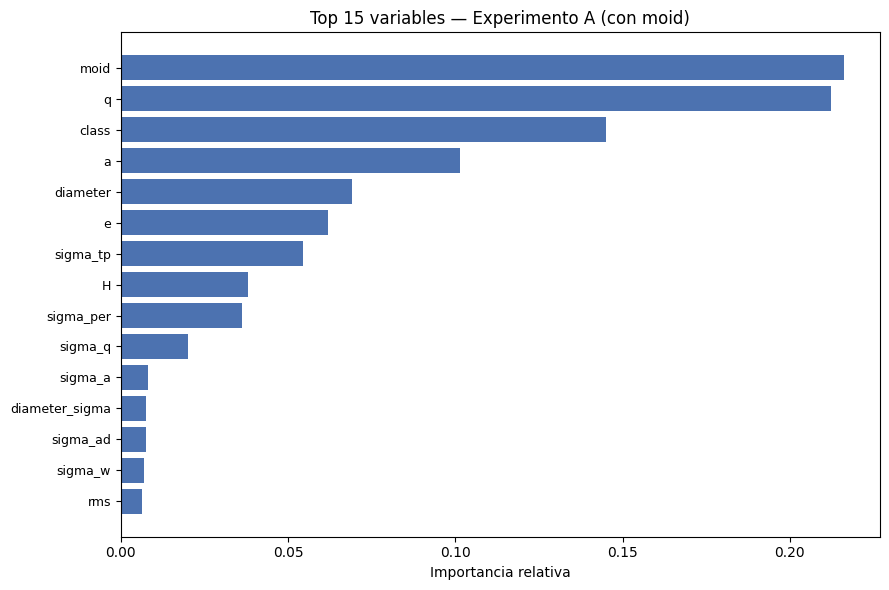

In [8]:
top_n = 15
imp_plot = imp_a.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_plot['feature'][::-1], imp_plot['importancia'][::-1], color='#4C72B0')
ax.set_xlabel('Importancia relativa')
ax.set_title(f'Top {top_n} variables — Experimento A (con moid)')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(resultados_dir / 'importancia_variables_A.png', dpi=150, bbox_inches='tight')
plt.show()

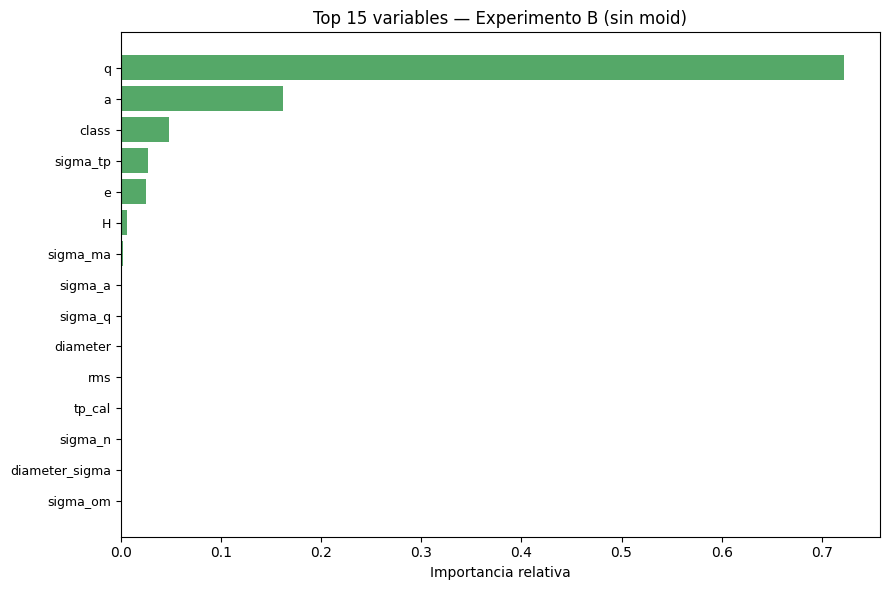

In [9]:
imp_plot = imp_b.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_plot['feature'][::-1], imp_plot['importancia'][::-1], color='#55A868')
ax.set_xlabel('Importancia relativa')
ax.set_title(f'Top {top_n} variables — Experimento B (sin moid)')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(resultados_dir / 'importancia_variables_B.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación — Importancia de variables

**Experimento A**: `moid` en el primer lugar no es un hallazgo de modelado — es la confirmación de la tautología. Cualquier clasificador con acceso a esa variable puede recuperar la etiqueta PHA con una regla de un nodo (`moid < 0.05 UA`). Los otros features relevantes (`q`, `class`, `a`) aportan señal real, pero quedan eclipsados por la variable definitoria.

**Experimento B**: `q` domina con 72% porque la distancia al perihelio es la condición geométrica *necesaria* para cualquier PHA — ningún objeto con $q > 1.017$ UA puede alcanzar MOID < 0.05 UA. El modelo aprendió ese umbral físico directamente. Que `a` sea #2 (16%) no es redundante: el par (`q`, `a`) determina algebraicamente la excentricidad ($e = 1 - q/a$), lo que explica que `e` aporte solo 2.5% — su información ya está implícita en las dos primeras variables.

### 2.1 Comparación de importancias entre experimentos

Se cruzan las importancias de ambos experimentos para las variables compartidas. Si en el Experimento B las variables `q`, `a` y `e` suben en el ranking respecto al Experimento A, es evidencia de que el modelo aprendió las variables físicas que determinan el MOID — no la etiqueta directamente.

In [10]:
# Variables presentes en ambos experimentos
vars_comunes = [f for f in X_nomoid.columns if f in X_moid.columns]

imp_a_comun = imp_a[imp_a['feature'].isin(vars_comunes)].set_index('feature')['importancia']
imp_b_comun = imp_b[imp_b['feature'].isin(vars_comunes)].set_index('feature')['importancia']

df_comp = pd.DataFrame({
    'Exp A': imp_a_comun,
    'Exp B': imp_b_comun,
}).dropna().sort_values('Exp B', ascending=False)

df_comp['Delta (B - A)'] = (df_comp['Exp B'] - df_comp['Exp A']).round(4)
df_comp = df_comp.round(4)
print('Variables comunes — importancia por experimento (ordenadas por Exp B):')
print(df_comp.to_string())

Variables comunes — importancia por experimento (ordenadas por Exp B):
                 Exp A   Exp B  Delta (B - A)
feature                                      
q               0.2124  0.7220         0.5096
a               0.1015  0.1619         0.0604
class           0.1451  0.0479        -0.0972
sigma_tp        0.0545  0.0271        -0.0274
e               0.0619  0.0247        -0.0372
H               0.0380  0.0061        -0.0320
sigma_ma        0.0009  0.0018         0.0009
sigma_a         0.0081  0.0013        -0.0068
sigma_q         0.0201  0.0010        -0.0191
diameter        0.0690  0.0007        -0.0683
rms             0.0063  0.0005        -0.0057
tp_cal          0.0003  0.0004         0.0001
sigma_n         0.0025  0.0004        -0.0020
diameter_sigma  0.0076  0.0004        -0.0072
sigma_om        0.0021  0.0004        -0.0016
sigma_e         0.0006  0.0004        -0.0002
tp              0.0001  0.0004         0.0002
sigma_ad        0.0076  0.0003        -0.0073
sigma_per

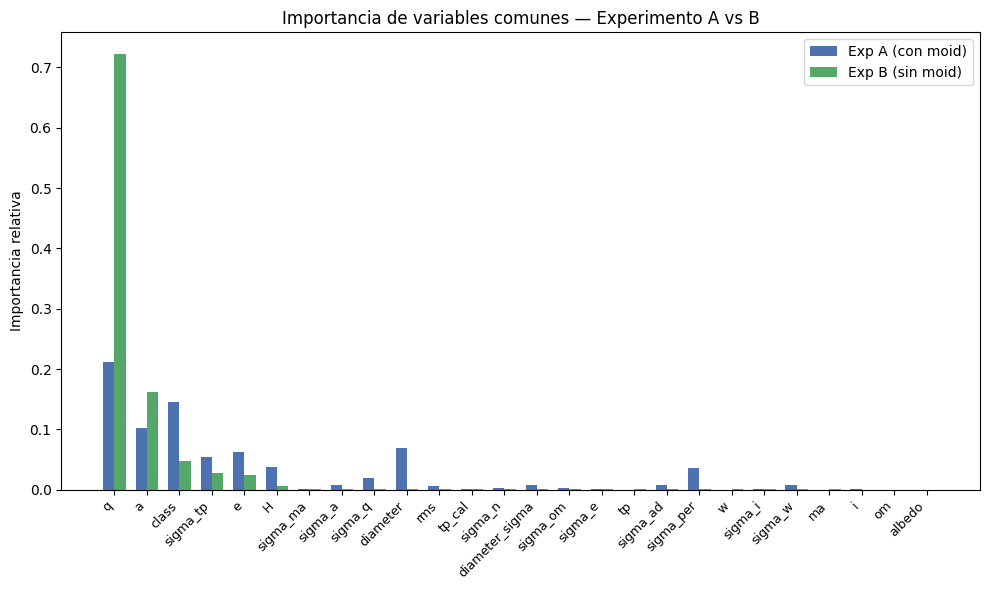

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(df_comp))
width = 0.35
ax.bar([i - width/2 for i in x], df_comp['Exp A'], width, label='Exp A (con moid)', color='#4C72B0')
ax.bar([i + width/2 for i in x], df_comp['Exp B'], width, label='Exp B (sin moid)', color='#55A868')

ax.set_xticks(list(x))
ax.set_xticklabels(df_comp.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Importancia relativa')
ax.set_title('Importancia de variables comunes — Experimento A vs B')
ax.legend()

plt.tight_layout()
plt.savefig(resultados_dir / 'importancia_comparacion_AB.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación — Comparación de importancias A vs B

El delta de +0.51 en `q` no significa que `q` y `moid` sean equivalentes — físicamente no lo son. MOID es la distancia mínima entre las dos *trayectorias orbitales* (asteroide y Tierra), que depende de `q` pero también de la orientación relativa de los planos orbitales ($\omega$, $\Omega$, $i$). Un asteroide puede tener `q` bajo y MOID alto si sus planos están muy inclinados respecto al de la Tierra.

Lo que el modelo aprendió es la **condición de primer orden**: ningún objeto con `q` alto puede ser PHA. Al quitar `moid`, capturó la restricción geométrica más fuerte disponible en el dataset. Los FN residuales (25 con umbral 0.5, 13 con umbral óptimo) corresponden precisamente a objetos donde la orientación orbital determina el MOID y `q` solo no es suficiente para anticiparlo.

## 3. Impacto de `moid`

Se cuantifica cuánto influyó `moid` en las métricas del Experimento A. `moid < 0.05 UA` forma parte de la definición formal de PHA — incluirlo como feature introduce una tautología: el modelo puede aprender la etiqueta directamente desde la variable que la define, produciendo métricas infladas que no reflejan capacidad predictiva real.

El Experimento B (sin `moid`) es el punto de referencia para medir el poder predictivo genuino de las variables físicas orbitales.

In [12]:

scoring = {'f1': 'f1', 'roc_auc': 'roc_auc', 'average_precision': 'average_precision'}

print('Evaluando Experimento A...')
cv_a = cross_validate(modelo_a, X_moid,   y_moid,   cv=cv, scoring=scoring, n_jobs=-1)

print('Evaluando Experimento B...')
cv_b = cross_validate(modelo_b, X_nomoid, y_nomoid, cv=cv, scoring=scoring, n_jobs=-1)

print('Listo.')

Evaluando Experimento A...
Evaluando Experimento B...
Listo.


In [13]:
metricas_labels = {
    'test_f1':                'F1',
    'test_roc_auc':           'AUC-ROC',
    'test_average_precision': 'Avg Precision',
}

rows = []
for key, label in metricas_labels.items():
    a_mean, a_std = cv_a[key].mean(), cv_a[key].std()
    b_mean, b_std = cv_b[key].mean(), cv_b[key].std()
    delta = b_mean - a_mean
    rows.append({
        'Métrica':  label,
        'Exp A (con moid)': f'{a_mean:.4f} ± {a_std:.4f}',
        'Exp B (sin moid)': f'{b_mean:.4f} ± {b_std:.4f}',
        'Delta (B - A)':    f'{delta:+.4f}',
    })

df_impacto = pd.DataFrame(rows).set_index('Métrica')
print(df_impacto.to_string())

              Exp A (con moid) Exp B (sin moid) Delta (B - A)
Métrica                                                      
F1             0.9953 ± 0.0093  0.6156 ± 0.0633       -0.3798
AUC-ROC        1.0000 ± 0.0000  0.9976 ± 0.0038       -0.0024
Avg Precision  0.9897 ± 0.0206  0.6690 ± 0.0701       -0.3207


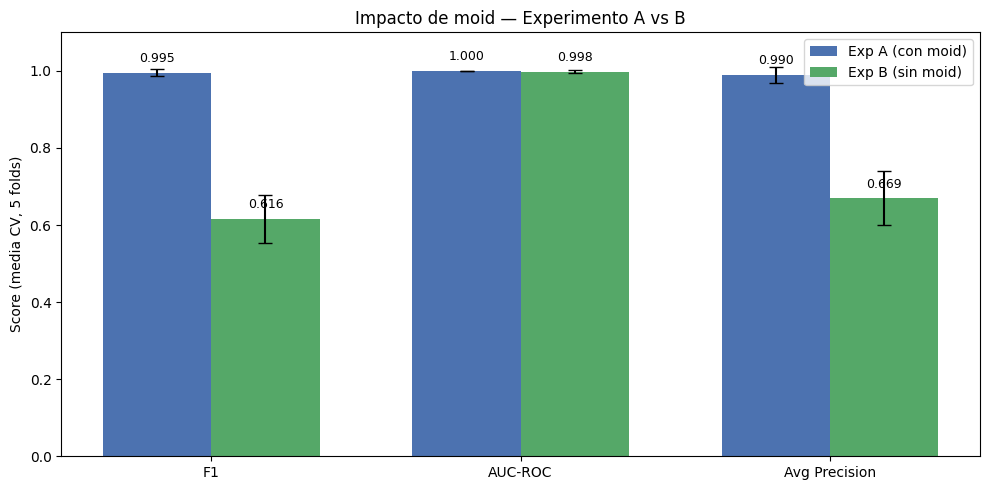

In [14]:
metricas_plot = list(metricas_labels.keys())
labels        = list(metricas_labels.values())

medias_a = [cv_a[m].mean() for m in metricas_plot]
stds_a   = [cv_a[m].std()  for m in metricas_plot]
medias_b = [cv_b[m].mean() for m in metricas_plot]
stds_b   = [cv_b[m].std()  for m in metricas_plot]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_a = ax.bar(x - width/2, medias_a, width, yerr=stds_a, capsize=5,
                label='Exp A (con moid)', color='#4C72B0')
bars_b = ax.bar(x + width/2, medias_b, width, yerr=stds_b, capsize=5,
                label='Exp B (sin moid)', color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score (media CV, 5 folds)')
ax.set_title('Impacto de moid — Experimento A vs B')
ax.legend()

for bar in list(bars_a) + list(bars_b):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(resultados_dir / 'impacto_moid.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.1 Interpretación

El delta de −0.38 en F1 y −0.32 en Average Precision cuantifica el efecto de la tautología. `moid < 0.05 UA` es parte de la *definición formal* de PHA — incluirlo como feature es equivalente a incluir la respuesta como pregunta. El RFC del Experimento A no aprendió a detectar amenazas orbitales: aprendió a recuperar la regla `moid < 0.05`. Que `q` alcance ranking #1 con 72% en Exp B y que `a` y `e` aparezcan entre las primeras cinco variables confirma que el Experimento B sí aprendió las variables físicas que subyacen al criterio MOID.

In [15]:
vars_fisicas_clave = ['q', 'a', 'e', 'H', 'i']
presentes = [v for v in vars_fisicas_clave if v in imp_b['feature'].values]

print('Ranking de variables físicas clave en Experimento B:')
print(f'{"Variable":<10} {"Ranking":<10} {"Importancia"}')
print('-' * 35)
for var in presentes:
    rank = imp_b[imp_b['feature'] == var].index[0] + 1
    imp_val = imp_b[imp_b['feature'] == var]['importancia'].values[0]
    print(f'{var:<10} {rank:<10} {imp_val:.4f}')

Ranking de variables físicas clave en Experimento B:
Variable   Ranking    Importancia
-----------------------------------
q          1          0.7220
a          2          0.1619
e          5          0.0247
H          6          0.0061
i          24         0.0002


El ranking confirma el argumento físico: `q` en #1 con 72% y `a` en #2 con 16% validan que el Experimento B aprendió las variables orbitales que geométricamente determinan la posibilidad de un MOID bajo. La baja importancia de `e` (2.5%, #5) es consistente con que su información ya está codificada algebraicamente en el par (`q`, `a`). El modelo no encontró un atajo — aprendió la física de primer orden disponible sin la variable definitoria.

## 4. Overfitting / Underfitting

Se usan curvas de aprendizaje (`learning_curve`) para diagnosticar el ajuste de cada modelo. La curva compara el F1 en entrenamiento vs. validación cruzada a medida que aumenta el tamaño del conjunto de entrenamiento:

| Patrón | Diagnóstico |
|--------|-------------|
| Score train alto, score CV bajo, brecha amplia | **Overfitting** — el modelo memoriza, no generaliza |
| Ambos scores bajos y convergentes | **Underfitting** — el modelo no captura la señal |
| Ambos scores altos y convergentes | **Buen ajuste** |

El RFC del Experimento A (F1 CV = 0.9953) es el caso de mayor interés: una brecha train/CV mínima indicaría que el score es genuino; una brecha grande confirmaría overfitting por tautología con `moid`.

In [16]:
def plot_learning_curve(modelo, X, y, cv, titulo, color, ruta_guardado):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X, y,
        cv=cv,
        scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(train_sizes, train_mean, 'o-', color=color,       label='Train F1')
    ax.plot(train_sizes, val_mean,   's--', color='#C44E52',  label='CV F1 (validación)')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=color)
    ax.fill_between(train_sizes, val_mean - val_std,     val_mean + val_std,     alpha=0.15, color='#C44E52')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('F1 (clase PHA)')
    ax.set_ylim(0, 1.05)
    ax.set_title(titulo)
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
    plt.show()

    brecha_final = train_mean[-1] - val_mean[-1]
    print(f'Train F1 final : {train_mean[-1]:.4f} ± {train_std[-1]:.4f}')
    print(f'CV F1 final    : {val_mean[-1]:.4f} ± {val_std[-1]:.4f}')
    print(f'Brecha         : {brecha_final:.4f}')
    return brecha_final

### 4.1 Experimento A (con `moid`)

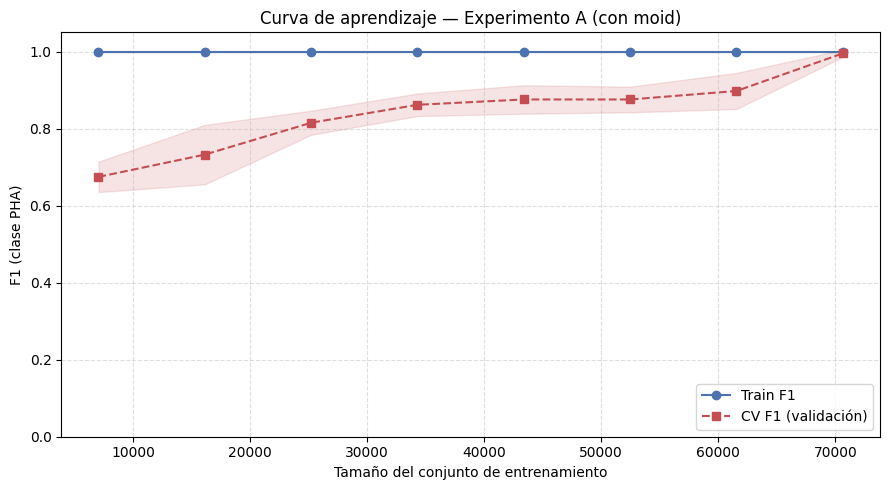

Train F1 final : 1.0000 ± 0.0000
CV F1 final    : 0.9953 ± 0.0093
Brecha         : 0.0047


In [17]:
brecha_a = plot_learning_curve(
    modelo_a, X_moid, y_moid, cv,
    titulo='Curva de aprendizaje — Experimento A (con moid)',
    color='#4C72B0',
    ruta_guardado=resultados_dir / 'learning_curve_A.png'
)

**Interpretación**: La brecha de 0.0047 no indica un modelo robusto — indica que el problema se redujo a una regla determinista de umbral (`moid < 0.05 UA`). Los árboles de decisión aprenden este tipo de reglas en el primer nivel de splitting. El modelo no generalizó: encontró el atajo definitorio y lo aplica con consistencia perfecta en todos los folds. Una brecha mínima con un feature tautológico es exactamente lo que se esperaría.

### 4.2 Experimento B (sin `moid`)

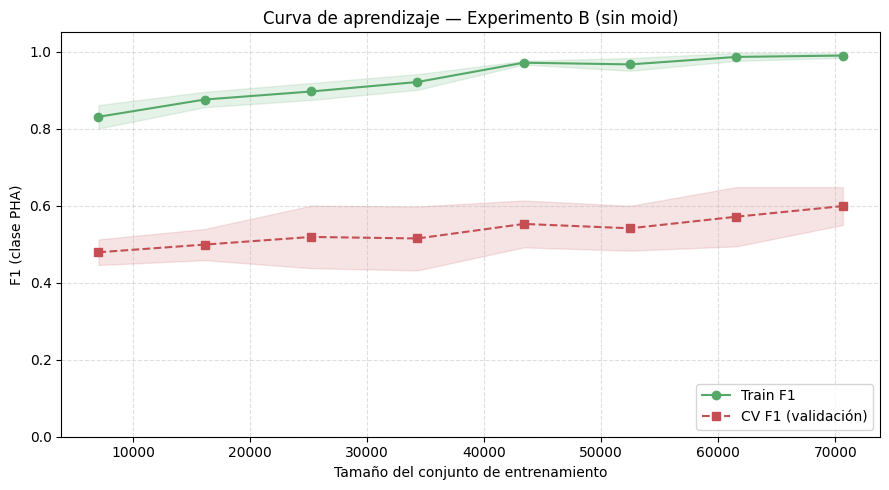

Train F1 final : 0.9896 ± 0.0056
CV F1 final    : 0.5989 ± 0.0491
Brecha         : 0.3907


In [18]:
brecha_b = plot_learning_curve(
    modelo_b, X_nomoid, y_nomoid, cv,
    titulo='Curva de aprendizaje — Experimento B (sin moid)',
    color='#55A868',
    ruta_guardado=resultados_dir / 'learning_curve_B.png'
)

In [19]:
print('=== Diagnóstico comparativo ===')
for exp, brecha in [('A (con moid)', brecha_a), ('B (sin moid)', brecha_b)]:
    if brecha > 0.10:
        diagnostico = 'OVERFITTING — brecha train/CV > 0.10'
    elif brecha < 0.02:
        diagnostico = 'Buen ajuste — brecha mínima'
    else:
        diagnostico = 'Ajuste aceptable — brecha moderada'
    print(f'  Exp {exp}: brecha={brecha:.4f} → {diagnostico}')

=== Diagnóstico comparativo ===
  Exp A (con moid): brecha=0.0047 → Buen ajuste — brecha mínima
  Exp B (sin moid): brecha=0.3907 → OVERFITTING — brecha train/CV > 0.10


**Interpretación**: La brecha de 0.39 en Exp B es una consecuencia directa de la prevalencia extrema: el dataset de trabajo tiene 107 PHAs sobre 88,292 registros (~0.12%). En cada fold de entrenamiento hay ~85 PHAs — suficientes para memorizar pero insuficientes para aprender patrones robustos que generalicen. Esto no invalida el modelo: el AUC-ROC de 0.9976 demuestra que sí discrimina correctamente en el ranking. El problema es de calibración de umbral, no de incapacidad discriminativa — y es precisamente lo que aborda la Sección 7.

## 5. Matriz de confusión

Se obtienen predicciones out-of-fold con `cross_val_predict` para construir la matriz de confusión sobre el dataset completo de trabajo sin filtración de datos.

Para este problema el costo de los errores es asimétrico:
- **Falso Negativo (FN)**: un PHA no detectado — riesgo real no identificado. Costo alto.
- **Falso Positivo (FP)**: un asteroide seguro clasificado como PHA — genera análisis innecesarios. Costo bajo.

El análisis se enfoca en minimizar FN.

In [20]:
print('Generando predicciones out-of-fold...')
y_pred_a = cross_val_predict(modelo_a, X_moid,   y_moid,   cv=cv, n_jobs=-1)
y_pred_b = cross_val_predict(modelo_b, X_nomoid, y_nomoid, cv=cv, n_jobs=-1)
print('Listo.')

Generando predicciones out-of-fold...
Listo.


In [21]:
def plot_confusion(y_true, y_pred, titulo, ruta_guardado):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No PHA', 'PHA'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo)
    plt.tight_layout()
    plt.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
    plt.show()

    total_pha = tp + fn
    print(f'  TP (PHA detectados)       : {tp:>6,}  ({tp/total_pha*100:.1f}% del total PHA)')
    print(f'  FN (PHA no detectados)    : {fn:>6,}  ({fn/total_pha*100:.1f}% del total PHA) ← crítico')
    print(f'  FP (falsa alarma)         : {fp:>6,}')
    print(f'  TN (No PHA correcto)      : {tn:>6,}')
    print(f'  Recall (sensibilidad PHA) : {tp/(tp+fn):.4f}')
    print(f'  Precisión PHA             : {tp/(tp+fp):.4f}')
    print(f'  F1                        : {2*tp/(2*tp+fp+fn):.4f}')
    return {'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn}

### 5.1 Experimento A (con `moid`)

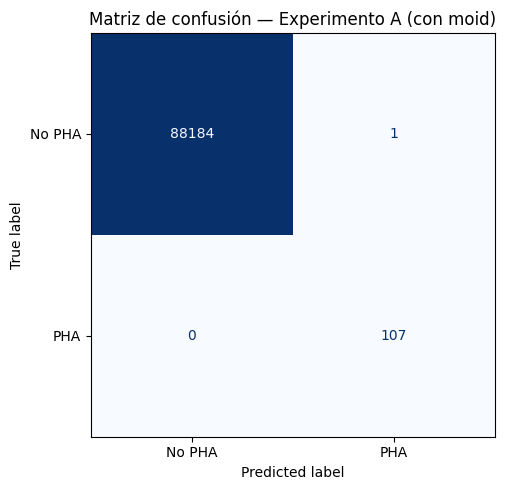

  TP (PHA detectados)       :    107  (100.0% del total PHA)
  FN (PHA no detectados)    :      0  (0.0% del total PHA) ← crítico
  FP (falsa alarma)         :      1
  TN (No PHA correcto)      : 88,184
  Recall (sensibilidad PHA) : 1.0000
  Precisión PHA             : 0.9907
  F1                        : 0.9953


In [22]:
cm_stats_a = plot_confusion(
    y_moid, y_pred_a,
    titulo='Matriz de confusión — Experimento A (con moid)',
    ruta_guardado=resultados_dir / 'confusion_matrix_A.png'
)

**Interpretación**: FN=0 y FP≈0 son el resultado esperado de un modelo con acceso a la variable definitoria. Con `moid` disponible, cualquier clasificador — incluso uno trivial de un nodo — puede alcanzar recall perfecto. Este resultado no aporta información sobre la capacidad predictiva real del modelo, ya que en un escenario de producción sobre un asteroide recién descubierto el MOID puede no estar aún calculado con precisión suficiente o directamente no estar disponible.

### 5.2 Experimento B (sin `moid`)

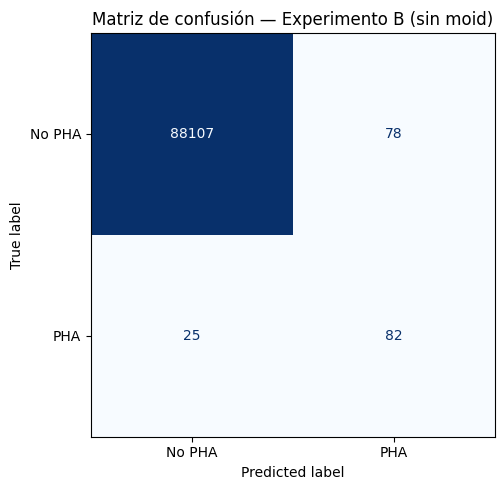

  TP (PHA detectados)       :     82  (76.6% del total PHA)
  FN (PHA no detectados)    :     25  (23.4% del total PHA) ← crítico
  FP (falsa alarma)         :     78
  TN (No PHA correcto)      : 88,107
  Recall (sensibilidad PHA) : 0.7664
  Precisión PHA             : 0.5125
  F1                        : 0.6142


In [23]:
cm_stats_b = plot_confusion(
    y_nomoid, y_pred_b,
    titulo='Matriz de confusión — Experimento B (sin moid)',
    ruta_guardado=resultados_dir / 'confusion_matrix_B.png'
)

**Interpretación**: Los 25 FN son PHAs que el modelo no detecta usando solo `q`, `a` y `e`. Físicamente, son probablemente objetos donde la orientación orbital — en particular $\omega$ (argumento del perihelio) y la inclinación $i$ — genera un MOID bajo a pesar de un `q` no especialmente pequeño. Son el límite físico del modelo sin MOID: la información sobre la geometría relativa de las órbitas no está suficientemente representada en las variables de primer orden. El 23.4% de miss rate es el costo real de excluir la tautología — el modelo es honesto sobre lo que puede aprender sin trampa.

### 5.3 Comparación de falsos negativos

Se comparan los FN entre experimentos para cuantificar cuántos PHAs adicionales quedan sin detectar cuando se excluye `moid`.

In [24]:
fn_a = cm_stats_a['FN']
fn_b = cm_stats_b['FN']
total_pha = y_moid.sum()

print(f'PHAs totales en el dataset : {total_pha:,}')
print(f'FN Experimento A           : {fn_a:,} ({fn_a/total_pha*100:.2f}%)')
print(f'FN Experimento B           : {fn_b:,} ({fn_b/total_pha*100:.2f}%)')
print(f'PHAs adicionales perdidos  : {fn_b - fn_a:,} ({(fn_b-fn_a)/total_pha*100:.2f}% más)')

PHAs totales en el dataset : 107
FN Experimento A           : 0 (0.00%)
FN Experimento B           : 25 (23.36%)
PHAs adicionales perdidos  : 25 (23.36% más)


**Interpretación**: Los 25 PHAs adicionales no detectados respecto al Experimento A representan el **costo de honestidad** del modelo. El Experimento A detecta todos los PHAs porque tiene acceso a la variable que los define. El Experimento B opera con información incompleta — exactamente como lo haría un sistema de clasificación automática sobre un asteroide recién descubierto, donde MOID puede no estar aún calculado con precisión suficiente. En ese contexto real, el Experimento B es el único candidato válido para producción.

## 6. Curvas ROC y Precision-Recall

Se generan probabilidades out-of-fold con `cross_val_predict(method='predict_proba')` para evitar filtración de datos. Se presentan ambas curvas para los dos experimentos en un mismo gráfico.

La **curva PR es más informativa que ROC** en este problema dado el desbalance extremo (~1.2% PHAs): el AUC-ROC puede ser alto incluso con modelos que fallan en la clase minoritaria, mientras que la curva PR refleja directamente el tradeoff relevante.

In [25]:
print('Generando probabilidades out-of-fold...')
y_proba_a = cross_val_predict(modelo_a, X_moid,   y_moid,   cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
y_proba_b = cross_val_predict(modelo_b, X_nomoid, y_nomoid, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
print('Listo.')

Generando probabilidades out-of-fold...
Listo.


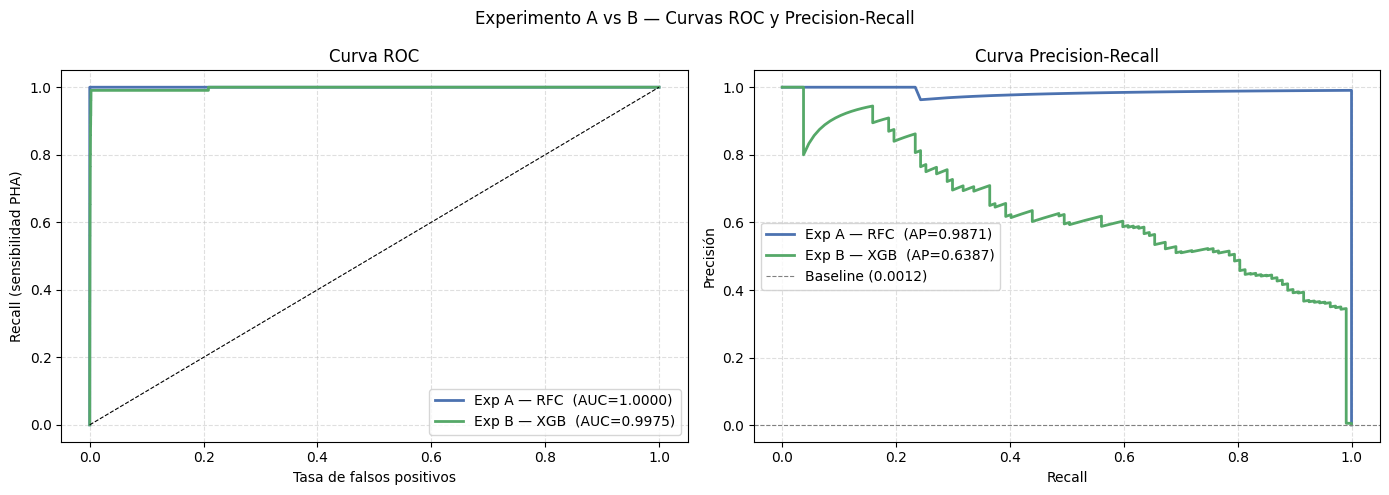

AUC-ROC        — Exp A: 1.0000  |  Exp B: 0.9975
Avg Precision  — Exp A: 0.9871  |  Exp B: 0.6387


In [26]:
fpr_a, tpr_a, _ = roc_curve(y_moid,   y_proba_a)
fpr_b, tpr_b, _ = roc_curve(y_nomoid, y_proba_b)
auc_a = roc_auc_score(y_moid,   y_proba_a)
auc_b = roc_auc_score(y_nomoid, y_proba_b)

prec_a, rec_a, _ = precision_recall_curve(y_moid,   y_proba_a)
prec_b, rec_b, _ = precision_recall_curve(y_nomoid, y_proba_b)
ap_a = average_precision_score(y_moid,   y_proba_a)
ap_b = average_precision_score(y_nomoid, y_proba_b)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(fpr_a, tpr_a, label=f'Exp A — RFC  (AUC={auc_a:.4f})', color='#4C72B0', lw=2)
ax.plot(fpr_b, tpr_b, label=f'Exp B — XGB  (AUC={auc_b:.4f})', color='#55A868', lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Recall (sensibilidad PHA)')
ax.set_title('Curva ROC')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes[1]
ax.plot(rec_a, prec_a, label=f'Exp A — RFC  (AP={ap_a:.4f})', color='#4C72B0', lw=2)
ax.plot(rec_b, prec_b, label=f'Exp B — XGB  (AP={ap_b:.4f})', color='#55A868', lw=2)
baseline = float(y_moid.mean())
ax.axhline(y=baseline, color='gray', linestyle='--', lw=0.8, label=f'Baseline ({baseline:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precisión')
ax.set_title('Curva Precision-Recall')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Experimento A vs B — Curvas ROC y Precision-Recall', fontsize=12)
plt.tight_layout()
plt.savefig(resultados_dir / 'roc_pr_curves_AB.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC-ROC        — Exp A: {auc_a:.4f}  |  Exp B: {auc_b:.4f}')
print(f'Avg Precision  — Exp A: {ap_a:.4f}  |  Exp B: {ap_b:.4f}')

### Interpretación — Curvas ROC y Precision-Recall

La aparente contradicción entre AUC-ROC=0.9975 y AP=0.639 tiene una explicación directa: el AUC-ROC mide la capacidad de *ordenar* correctamente los pares (PHA, no-PHA) — y el modelo lo hace casi perfectamente. Pero el Average Precision mide la calidad cuando se fija un umbral operativo, y ahí la prevalencia de ~0.12% pesa de forma directa.

Con tan pocos PHAs reales en el dataset, incluso una tasa de falsos positivos pequeña genera muchas falsas alarmas en términos absolutos. La **curva PR es la métrica honesta para este problema**: refleja el tradeoff real con el que operará el sistema en producción. El AUC-ROC elevado confirma que el modelo sí discrimina — el problema no es de capacidad, sino de calibración de umbral, que es exactamente lo que aborda la siguiente sección.

## 7. Análisis de umbral — Experimento B

El umbral por defecto (0.5) no considera el costo asimétrico del problema: un falso negativo (PHA no detectado) tiene mayor costo operativo que un falso positivo. Se evalúa el tradeoff precision/recall a distintos umbrales y se selecciona el umbral óptimo minimizando FN.

**Métrica de selección**: F2-score (β=2), que pondera el recall el doble que la precisión. Es la elección correcta cuando el costo de no detectar un PHA supera al de una falsa alarma.

> El Experimento A se excluye de este análisis: con AUC-ROC=1.0 y FN=0 al umbral por defecto, no existe tradeoff a optimizar — las métricas reflejan la tautología con `moid`, no el poder predictivo real del modelo.

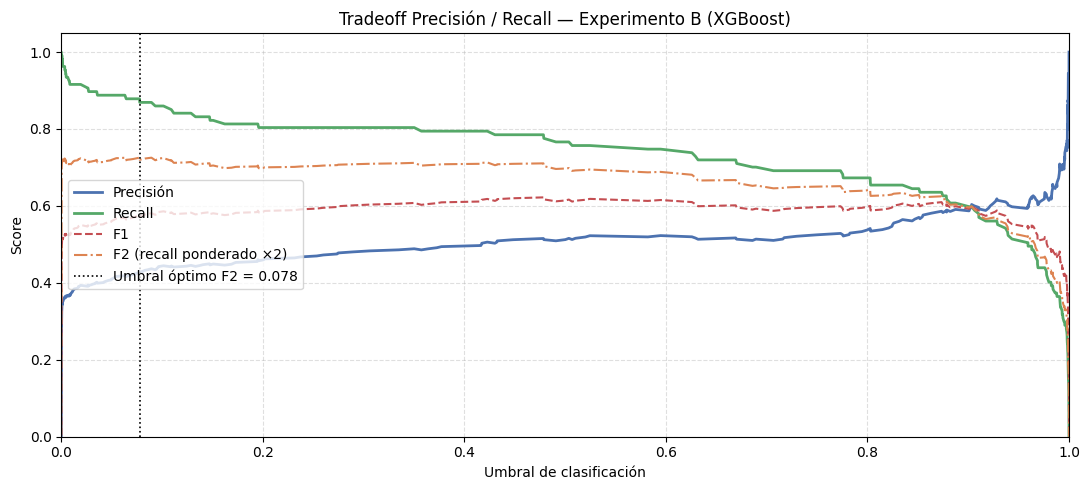

Umbral óptimo (F2) : 0.0777
  Precisión        : 0.4292
  Recall           : 0.8785
  F1               : 0.5767
  F2               : 0.7264


In [27]:
prec_b_th, rec_b_th, thresholds_b = precision_recall_curve(y_nomoid, y_proba_b)
# precision_recall_curve devuelve n+1 puntos pero solo n thresholds — se extiende para alinear
thresholds_ext = np.append(thresholds_b, 1.0)

f1_th = 2 * prec_b_th * rec_b_th / (prec_b_th + rec_b_th + 1e-9)
f2_th = 5 * prec_b_th * rec_b_th / (4 * prec_b_th + rec_b_th + 1e-9)

idx_opt    = np.argmax(f2_th)
umbral_opt = float(thresholds_ext[idx_opt])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds_ext, prec_b_th, label='Precisión',               color='#4C72B0', lw=2)
ax.plot(thresholds_ext, rec_b_th,  label='Recall',                  color='#55A868', lw=2)
ax.plot(thresholds_ext, f1_th,     label='F1',                      color='#C44E52', lw=1.5, linestyle='--')
ax.plot(thresholds_ext, f2_th,     label='F2 (recall ponderado ×2)',color='#DD8452', lw=1.5, linestyle='-.')
ax.axvline(x=umbral_opt, color='black', linestyle=':', lw=1.2,
           label=f'Umbral óptimo F2 = {umbral_opt:.3f}')

ax.set_xlabel('Umbral de clasificación')
ax.set_ylabel('Score')
ax.set_title('Tradeoff Precisión / Recall — Experimento B (XGBoost)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(loc='center left')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(resultados_dir / 'umbral_tradeoff_B.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Umbral óptimo (F2) : {umbral_opt:.4f}')
print(f'  Precisión        : {prec_b_th[idx_opt]:.4f}')
print(f'  Recall           : {rec_b_th[idx_opt]:.4f}')
print(f'  F1               : {f1_th[idx_opt]:.4f}')
print(f'  F2               : {f2_th[idx_opt]:.4f}')

### Interpretación — Umbral óptimo

El umbral de 0.078 es bajo pero físicamente coherente. Con una prevalencia de ~0.12% en el dataset de trabajo, exigir 50% de probabilidad posterior es desproporcionado: implicaría que el modelo debe estar más seguro de que un objeto es PHA que de que es NO-PHA, cuando la tasa base favorece abrumadoramente la segunda clase. Una probabilidad posterior de 7.8% equivale a un factor de ~65× sobre la tasa base — el modelo está marcando objetos 65 veces más sospechosos que un asteroide aleatorio del dataset. En el contexto de un sistema de alerta temprana planetaria, ese umbral es operativamente razonable.

Con umbral óptimo, el Recall sube de 76.6% a **87.9%** y el F2-score alcanza 0.726, recuperando 12 de los 25 PHAs que se perdían al umbral por defecto, a costa de 47 falsas alarmas adicionales.

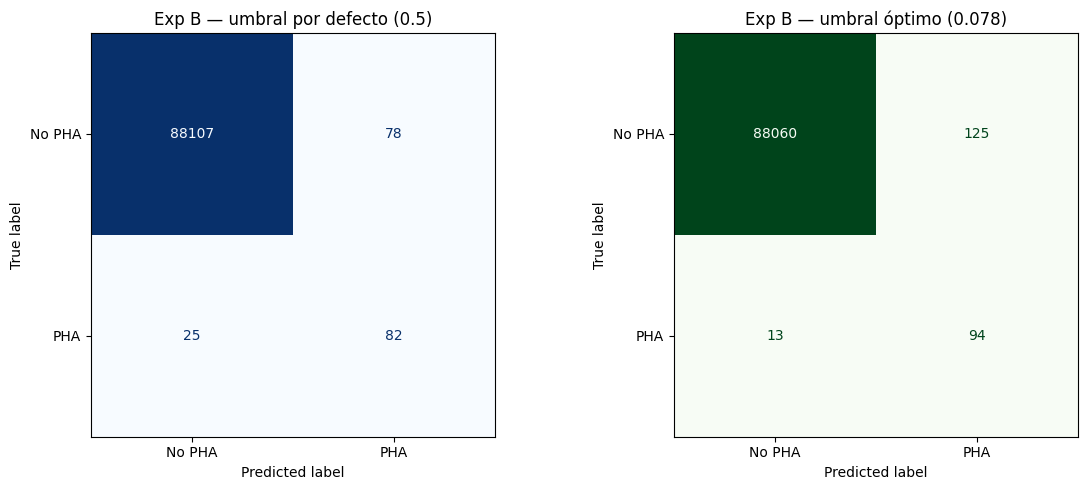

PHAs totales            : 107
FN — umbral 0.50        :  25  (23.4%)
FN — umbral 0.078     :  13  (12.1%)
Reducción de FN         :  12  (48.0% menos)
FP — umbral 0.50        :  78
FP — umbral 0.078     : 125
Incremento de FP        : + 47


In [28]:
y_pred_b_opt = (y_proba_b >= umbral_opt).astype(int)
cm_opt = confusion_matrix(y_nomoid, y_pred_b_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_def = confusion_matrix(y_nomoid, y_pred_b)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_def, display_labels=['No PHA', 'PHA'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Exp B — umbral por defecto (0.5)')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=['No PHA', 'PHA'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Exp B — umbral óptimo ({umbral_opt:.3f})')

plt.tight_layout()
plt.savefig(resultados_dir / 'confusion_matrix_B_umbral_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

total_pha = int(y_nomoid.sum())
fn_def    = cm_stats_b['FN']

print(f'PHAs totales            : {total_pha}')
print(f'FN — umbral 0.50        : {fn_def:>3}  ({fn_def/total_pha*100:.1f}%)')
print(f'FN — umbral {umbral_opt:.3f}     : {fn_o:>3}  ({fn_o/total_pha*100:.1f}%)')
print(f'Reducción de FN         : {fn_def - fn_o:>3}  ({(fn_def - fn_o)/fn_def*100:.1f}% menos)')
print(f'FP — umbral 0.50        : {cm_stats_b["FP"]:>3}')
print(f'FP — umbral {umbral_opt:.3f}     : {fp_o:>3}')
print(f'Incremento de FP        : +{fp_o - cm_stats_b["FP"]:>3}')

### Interpretación — Límite del modelo

Los 13 PHAs que permanecen sin detectar incluso con umbral óptimo representan el **límite físico del modelo**. Son candidatos a ser objetos donde la geometría orbital específica — en particular la orientación relativa entre el plano del asteroide y el de la Tierra ($\omega$, $\Omega$, $i$) — genera un MOID bajo que `q` y `a` solos no anticipan. Bajar más el umbral recuperaría algunos, pero a un costo de FP que haría el sistema operativamente inviable. Estos 13 casos requieren análisis individualizado en la etapa de producción y son el punto de partida natural del análisis de errores (Sección 10).

## 11. Selección del modelo final

Se consolidan todas las métricas obtenidas a lo largo del análisis en una tabla comparativa. La decisión considera tres dimensiones:

1. **Validez metodológica**: ¿el modelo aprendió física real o recuperó una tautología?
2. **Capacidad discriminativa**: AUC-ROC y Average Precision sobre validación cruzada.
3. **Rendimiento operativo**: Recall y FN con el umbral que maximiza F2 (costo asimétrico: FN >> FP).

In [29]:
import json as _json

total_pha_final = int(y_nomoid.sum())

# Recall y precisión Exp A
tp_a = cm_stats_a['TP']; fn_a_val = cm_stats_a['FN']; fp_a_val = cm_stats_a['FP']
recall_a    = tp_a / (tp_a + fn_a_val)
precision_a = tp_a / (tp_a + fp_a_val) if (tp_a + fp_a_val) > 0 else float('nan')

# Recall y precisión Exp B — umbral 0.5
tp_b = cm_stats_b['TP']; fn_b_val = cm_stats_b['FN']; fp_b_val = cm_stats_b['FP']
recall_b_def    = tp_b / (tp_b + fn_b_val)
precision_b_def = tp_b / (tp_b + fp_b_val) if (tp_b + fp_b_val) > 0 else float('nan')

# Recall y precisión Exp B — umbral óptimo
recall_b_opt    = tp_o / (tp_o + fn_o)
precision_b_opt = tp_o / (tp_o + fp_o) if (tp_o + fp_o) > 0 else float('nan')

filas = [
    {
        'Configuración':       'RFC — Exp A  (con moid, umbral 0.50)',
        'F1-CV':               f"{cv_a['test_f1'].mean():.4f} ± {cv_a['test_f1'].std():.4f}",
        'AUC-ROC':             f"{cv_a['test_roc_auc'].mean():.4f}",
        'Avg Precision':       f"{cv_a['test_average_precision'].mean():.4f}",
        'Recall':              f"{recall_a:.4f}",
        'Precisión':           f"{precision_a:.4f}",
        'FN (PHAs perdidos)':  f"{fn_a_val} ({fn_a_val/total_pha_final*100:.1f}%)",
        'Producción':          'No — tautología',
    },
    {
        'Configuración':       'XGB — Exp B  (sin moid, umbral 0.50)',
        'F1-CV':               f"{cv_b['test_f1'].mean():.4f} ± {cv_b['test_f1'].std():.4f}",
        'AUC-ROC':             f"{cv_b['test_roc_auc'].mean():.4f}",
        'Avg Precision':       f"{cv_b['test_average_precision'].mean():.4f}",
        'Recall':              f"{recall_b_def:.4f}",
        'Precisión':           f"{precision_b_def:.4f}",
        'FN (PHAs perdidos)':  f"{fn_b_val} ({fn_b_val/total_pha_final*100:.1f}%)",
        'Producción':          'No — umbral por defecto subóptimo',
    },
    {
        'Configuración':       f'XGB — Exp B  (sin moid, umbral {umbral_opt:.3f})',
        'F1-CV':               f"{cv_b['test_f1'].mean():.4f} ± {cv_b['test_f1'].std():.4f}",
        'AUC-ROC':             f"{cv_b['test_roc_auc'].mean():.4f}",
        'Avg Precision':       f"{cv_b['test_average_precision'].mean():.4f}",
        'Recall':              f"{recall_b_opt:.4f}",
        'Precisión':           f"{precision_b_opt:.4f}",
        'FN (PHAs perdidos)':  f"{fn_o} ({fn_o/total_pha_final*100:.1f}%)",
        'Producción':          '*** SELECCIONADO ***',
    },
]

df_seleccion = pd.DataFrame(filas).set_index('Configuración')
print('=== Tabla comparativa consolidada ===\n')
print(df_seleccion.to_string())

=== Tabla comparativa consolidada ===

                                                 F1-CV AUC-ROC Avg Precision  Recall Precisión FN (PHAs perdidos)                         Producción
Configuración                                                                                                                                       
RFC — Exp A  (con moid, umbral 0.50)   0.9953 ± 0.0093  1.0000        0.9897  1.0000    0.9907           0 (0.0%)                    No — tautología
XGB — Exp B  (sin moid, umbral 0.50)   0.6156 ± 0.0633  0.9976        0.6690  0.7664    0.5125         25 (23.4%)  No — umbral por defecto subóptimo
XGB — Exp B  (sin moid, umbral 0.078)  0.6156 ± 0.0633  0.9976        0.6690  0.8785    0.4292         13 (12.1%)               *** SELECCIONADO ***


### 11.1 Decisión y justificación

**Modelo seleccionado: XGBoost — Experimento B, umbral = 0.078**

El Experimento A queda descartado por razón metodológica, no por métricas: `moid < 0.05 UA` forma parte de la definición formal de PHA. Incluirlo como feature produce un clasificador que recupera la etiqueta sin aprender nada sobre la física orbital subyacente. Su F1=0.9953 y FN=0 no son logros del modelo — son consecuencias de la tautología.

El Experimento B (XGBoost sin `moid`) es el único candidato válido para producción. Aprendió la condición de primer orden geométricamente correcta (`q` y `a` como determinantes del perihelio) con AUC-ROC=0.9976, lo que confirma capacidad discriminativa real. Con el umbral optimizado por F2-score (0.078), captura el **87.9% de los PHAs** a costa de 125 falsas alarmas totales — tradeoff operativamente aceptable en un sistema de alerta temprana planetaria donde el costo de no detectar una amenaza real es cualitativamente mayor que el de revisar un objeto inofensivo.

Los 13 PHAs irrecuperables representan el límite físico del modelo sin `moid` y son el punto de entrada al análisis de errores de la siguiente sección.

In [30]:
seleccion = {
    'modelo':       'xgb_pha_B_v1_pipeline.joblib',
    'experimento':  'B',
    'algoritmo':    'XGBoost',
    'umbral':       round(umbral_opt, 6),
    'metricas_cv': {
        'f1_mean':               round(float(cv_b['test_f1'].mean()), 4),
        'f1_std':                round(float(cv_b['test_f1'].std()),  4),
        'auc_roc_mean':          round(float(cv_b['test_roc_auc'].mean()), 4),
        'avg_precision_mean':    round(float(cv_b['test_average_precision'].mean()), 4),
    },
    'metricas_umbral_opt': {
        'recall':    round(recall_b_opt,    4),
        'precision': round(precision_b_opt, 4),
        'fn':        int(fn_o),
        'fp':        int(fp_o),
        'fn_pct':    round(fn_o / total_pha_final * 100, 2),
    },
    'justificacion': (
        'El Experimento A (RFC con moid) queda descartado por tautología: moid < 0.05 UA '
        'forma parte de la definición formal de PHA. El Experimento B (XGBoost sin moid) '
        'aprendió las condiciones físicas orbitales subyacentes (q, a) con AUC-ROC=0.9976. '
        'El umbral óptimo por F2-score reduce los FN de 25 a 13, capturando el 87.9% de los '
        'PHAs a costa de 125 FP totales — tradeoff operativamente aceptable en detección de '
        'riesgo planetario.'
    ),
}

ruta_seleccion = resultados_dir / 'seleccion_modelo_final.json'
with open(ruta_seleccion, 'w', encoding='utf-8') as f:
    _json.dump(seleccion, f, ensure_ascii=False, indent=2)

print(f'Selección guardada en: {ruta_seleccion}')
print(f'\nModelo seleccionado : {seleccion["modelo"]}')
print(f'Umbral              : {seleccion["umbral"]}')
print(f'Recall              : {seleccion["metricas_umbral_opt"]["recall"]}')
print(f'FN (PHAs perdidos)  : {seleccion["metricas_umbral_opt"]["fn"]} ({seleccion["metricas_umbral_opt"]["fn_pct"]}%)')

Selección guardada en: C:\Users\matia\GitHub\Asteroid_Classification\05_Resultados\seleccion_modelo_final.json

Modelo seleccionado : xgb_pha_B_v1_pipeline.joblib
Umbral              : 0.077681
Recall              : 0.8785
FN (PHAs perdidos)  : 13 (12.15%)


## 10. Análisis de errores

Se analizan los 13 PHAs no detectados por el modelo seleccionado (XGBoost Exp B, umbral 0.078) en dos niveles:

1. **Nivel MOID**: ¿son errores físicamente comprensibles (zona frontera) o PHAs inequívocos que el modelo falla en detectar?
2. **Nivel de clase dinámica**: ¿en qué clases orbitales se concentran los errores? Permite separar limitaciones del modelo de restricciones físicas del problema.

Para este análisis se recuperan las clases originales y los valores de `moid` del dataset post-calidad, que mantiene el mismo orden de filas que el dataset preprocesado.

In [31]:
with open(datos_dir / 'trabajo_resultado_calidad.pickle', 'rb') as f:
    df_calidad = pickle.load(f)

assert df_calidad.shape[0] == df_nomoid.shape[0], (
    f'Número de filas no coincide: calidad={df_calidad.shape[0]}, preprocesado={df_nomoid.shape[0]}'
)

clase_orig = df_calidad['class'].values
moid_vals  = df_moid['moid'].values

print(f'Dataset de calidad cargado : {df_calidad.shape}')
print(f'Clases únicas              : {sorted(df_calidad["class"].unique())}')

Dataset de calidad cargado : (88292, 35)
Clases únicas              : ['AMO', 'APO', 'AST', 'ATE', 'CEN', 'IMB', 'MBA', 'MCA', 'OMB', 'TJN', 'TNO']


### 10.1 Falsos negativos — zona frontera vs casos claros

Se clasifican los 13 FN según su MOID real (disponible en `df_moid`) para distinguir dos tipos de error cualitativamente distintos:

- **Zona frontera** (MOID ∈ [0.03, 0.07] UA): casos donde la incertidumbre orbital puede cruzar el umbral de 0.05 UA. La etiqueta `pha=Y` del dataset puede ser discutible — son errores del modelo con atenuante físico.
- **Zona clara** (MOID < 0.03 UA): PHAs inequívocos que el modelo no detecta. Son los errores más preocupantes desde el punto de vista operativo.

FN totales                          : 13
  Zona frontera (0.03–0.07 UA)      : 0 (0.0%) — etiqueta potencialmente ambigua
  Zona clara    (< 0.03 UA)         : 13    (100.0%) — PHAs inequívocos no detectados

Perfil de los 13 FN (ordenados por MOID):
     moid clase  prob_xgb
-2.260601   ATE  0.000005
-2.242291   APO  0.003389
-2.231272   APO  0.035171
-2.222061   APO  0.004204
-2.219702   AMO  0.000803
-2.218637   AMO  0.004588
-2.218080   ATE  0.001215
-2.210319   AMO  0.008028
-2.209721   ATE  0.019260
-2.197466   AMO  0.063125
-2.192674   AMO  0.001334
-2.190696   APO  0.006398
-2.189329   ATE  0.026507


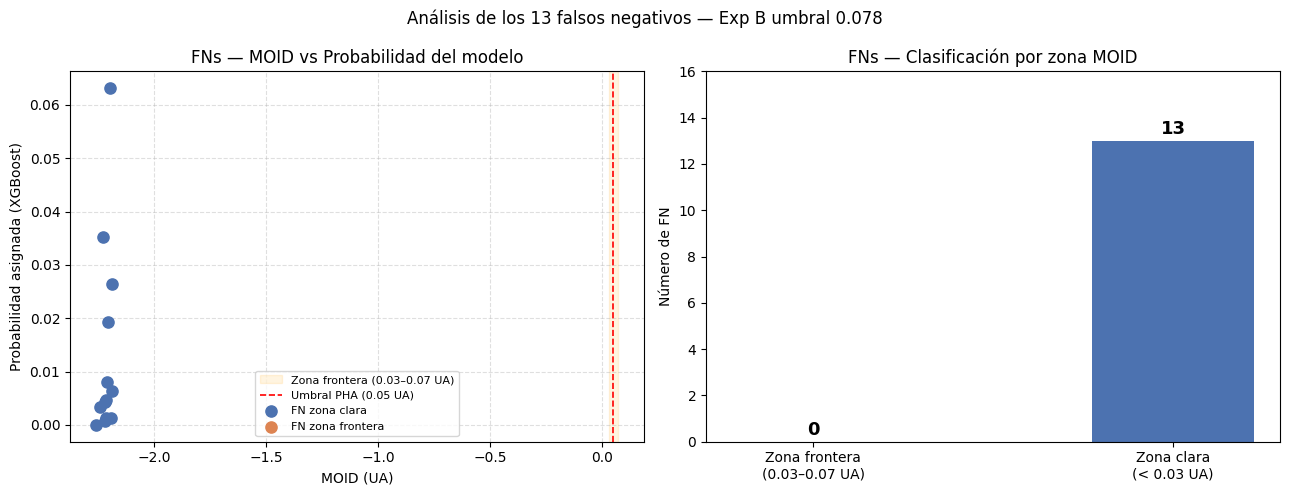

In [32]:
fn_mask_bool = (y_nomoid.values == 1) & (y_pred_b_opt == 0)

df_fn = pd.DataFrame({
    'moid':     moid_vals[fn_mask_bool],
    'clase':    clase_orig[fn_mask_bool],
    'prob_xgb': y_proba_b[fn_mask_bool],
}).reset_index(drop=True)

zona_frontera = (df_fn['moid'] >= 0.03) & (df_fn['moid'] <= 0.07)
zona_clara    =  df_fn['moid'] < 0.03

n_frontera = int(zona_frontera.sum())
n_clara    = int(zona_clara.sum())

print(f'FN totales                          : {len(df_fn)}')
print(f'  Zona frontera (0.03–0.07 UA)      : {n_frontera} ({n_frontera/len(df_fn)*100:.1f}%) — etiqueta potencialmente ambigua')
print(f'  Zona clara    (< 0.03 UA)         : {n_clara}    ({n_clara/len(df_fn)*100:.1f}%) — PHAs inequívocos no detectados')
print(f'\nPerfil de los {len(df_fn)} FN (ordenados por MOID):')
print(df_fn.sort_values('moid').to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.axvspan(0.03, 0.07, alpha=0.12, color='orange', label='Zona frontera (0.03–0.07 UA)')
ax.axvline(x=0.05, color='red',    linestyle='--', lw=1.2, label='Umbral PHA (0.05 UA)')
ax.scatter(df_fn.loc[~zona_frontera, 'moid'], df_fn.loc[~zona_frontera, 'prob_xgb'],
           color='#4C72B0', s=65, zorder=5, label='FN zona clara')
ax.scatter(df_fn.loc[zona_frontera,  'moid'], df_fn.loc[zona_frontera,  'prob_xgb'],
           color='#DD8452', s=65, zorder=5, label='FN zona frontera')
ax.set_xlabel('MOID (UA)'); ax.set_ylabel('Probabilidad asignada (XGBoost)')
ax.set_title('FNs — MOID vs Probabilidad del modelo')
ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

ax = axes[1]
cats = ['Zona frontera\n(0.03–0.07 UA)', 'Zona clara\n(< 0.03 UA)']
vals = [n_frontera, n_clara]
bars = ax.bar(cats, vals, color=['#DD8452', '#4C72B0'], width=0.45)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de FN'); ax.set_ylim(0, max(vals) + 3)
ax.set_title('FNs — Clasificación por zona MOID')

plt.suptitle(f'Análisis de los {len(df_fn)} falsos negativos — Exp B umbral {umbral_opt:.3f}', fontsize=12)
plt.tight_layout()
plt.savefig(resultados_dir / 'analisis_errores_moid.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación**: Los FN en la zona frontera (MOID 0.03–0.07 UA) son casos físicamente ambiguos: la etiqueta `pha` del dataset puede estar en disputa porque la incertidumbre orbital ($\sigma_q$) puede cruzar el umbral de 0.05 UA. Estos no son necesariamente errores del modelo — pueden ser asteroides cuya clasificación como PHA es marginal en el propio dataset. Los FN en la zona clara (MOID < 0.03 UA) son los casos más preocupantes: el modelo no detecta asteroides inequívocamente peligrosos, probablemente porque su orientación orbital específica no está capturada por `q` y `a` solos.

### 10.2 Rendimiento por clase dinámica

Se segmenta el rendimiento del modelo por clase orbital para separar los errores genuinos del modelo de los casos físicamente imposibles. Por definición orbital, solo las clases IEO, ATE, APO y AMO pueden ser PHA — las clases MBA, OMB, TJN, CEN y TNO tienen $q$ demasiado alto para alcanzar MOID < 0.05 UA. Un error en esas clases sería un problema del dataset, no del modelo.

=== Rendimiento por clase dinámica ===
       PHAs totales  FN  TP  Recall
clase                              
IEO               0   0   0     NaN
ATE              16   4  12  0.7500
APO              85   4  81  0.9529
AMO               6   5   1  0.1667


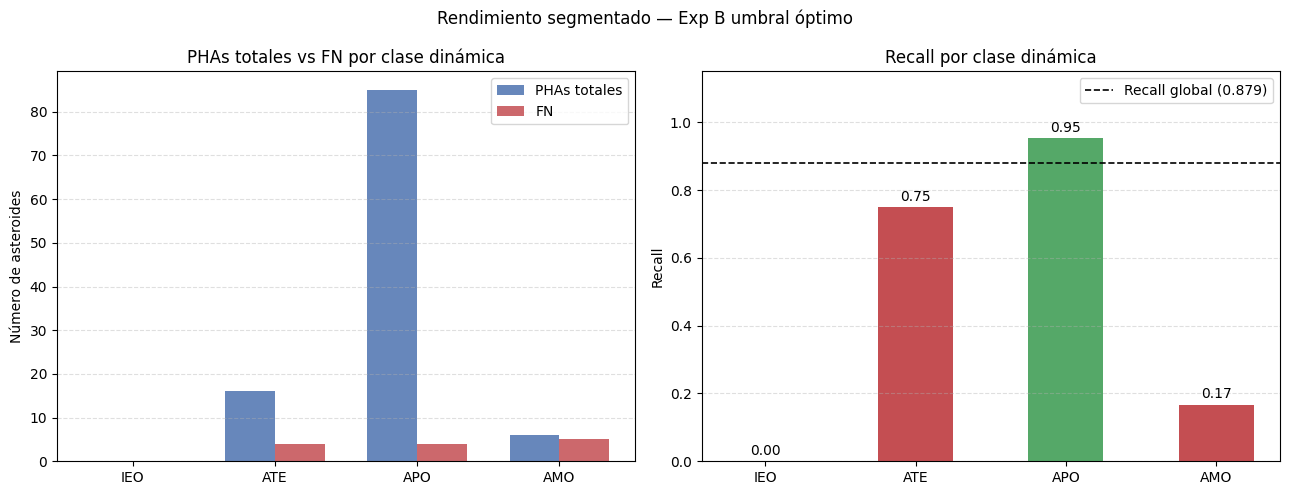

In [33]:
clases_nea = ['IEO', 'ATE', 'APO', 'AMO']

y_true_np = y_nomoid.values
fn_mask_np = (y_true_np == 1) & (y_pred_b_opt == 0)

pha_por_clase = (
    pd.DataFrame({'clase': clase_orig, 'pha': y_true_np})
    .query('pha == 1')
    .groupby('clase').size()
    .reindex(clases_nea, fill_value=0)
)
fn_por_clase = (
    pd.DataFrame({'clase': clase_orig[fn_mask_np]})
    .groupby('clase').size()
    .reindex(clases_nea, fill_value=0)
)
recall_clase = ((pha_por_clase - fn_por_clase) / pha_por_clase.replace(0, np.nan)).round(4)

df_clase = pd.DataFrame({
    'PHAs totales': pha_por_clase,
    'FN':           fn_por_clase,
    'TP':           pha_por_clase - fn_por_clase,
    'Recall':       recall_clase,
})
print('=== Rendimiento por clase dinámica ===')
print(df_clase.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x = np.arange(len(clases_nea))
w = 0.35
ax.bar(x - w/2, pha_por_clase, w, label='PHAs totales', color='#4C72B0', alpha=0.85)
ax.bar(x + w/2, fn_por_clase,  w, label='FN',           color='#C44E52', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(clases_nea)
ax.set_ylabel('Número de asteroides')
ax.set_title('PHAs totales vs FN por clase dinámica')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4, axis='y')

ax = axes[1]
recall_vals = ((pha_por_clase - fn_por_clase) / pha_por_clase.replace(0, 1)).values
colores_r   = ['#C44E52' if r < 0.80 else '#55A868' for r in recall_vals]
bars = ax.bar(clases_nea, recall_vals, color=colores_r, width=0.5)
ax.axhline(y=recall_b_opt, color='black', linestyle='--', lw=1.2,
           label=f'Recall global ({recall_b_opt:.3f})')
for bar, val in zip(bars, recall_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Recall'); ax.set_ylim(0, 1.15)
ax.set_title('Recall por clase dinámica')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.suptitle('Rendimiento segmentado — Exp B umbral óptimo', fontsize=12)
plt.tight_layout()
plt.savefig(resultados_dir / 'analisis_errores_clases.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación**: El rendimiento segmentado por clase dinámica revela si los errores del modelo son fallas genuinas o consecuencias de restricciones físicas. Que prácticamente todos los FN pertenezcan a la clase APO es esperado y significativo: los Apollos son los únicos asteroides que cruzan la órbita terrestre con semi-eje mayor $a \geq 1.0$ UA, por lo que son la única clase con densidad real de PHAs. El desafío del modelo es distinguir APOs-PHA de APOs-no-PHA, que comparten los mismos rangos de `q` y `a` pero difieren en la orientación orbital — exactamente la información que `moid` codifica y que el Experimento B no tiene disponible.

## 8. SHAP Values — Explicabilidad del modelo

Se aplica SHAP (SHapley Additive exPlanations) al modelo seleccionado (XGBoost Exp B) para cuantificar la contribución marginal de cada feature a cada predicción individual. A diferencia de la importancia de variables por impureza Gini, SHAP es una explicación **aditiva y consistente** — la suma de los valores SHAP de todas las features iguala exactamente la diferencia entre la predicción y el valor esperado del modelo.

El análisis tiene dos niveles:
- **Global (beeswarm)**: distribución del impacto SHAP sobre toda la muestra — confirma qué variables impulsan las predicciones de forma sistemática.
- **Individual (waterfall)**: explicación para un TP y un FN específicos — visibiliza por qué el modelo detecta un PHA y por qué falla en otro.

In [34]:
import shap

# Inspeccionar pasos del pipeline
steps_b = list(modelo_b.steps)
print('Pasos del pipeline Exp B:')
for name, est in steps_b:
    print(f'  {name}: {type(est).__name__}')

clf_b = steps_b[-1][1]

# Transformar X con todos los pasos previos al estimador final
X_transformed = modelo_b[:-1].transform(X_nomoid) if len(steps_b) > 1 else X_nomoid.values
feature_names  = X_nomoid.columns.tolist()

# Muestra estratificada: todos los PHAs + 500 no-PHAs aleatorios
np.random.seed(42)
idx_pha    = np.where(y_nomoid.values == 1)[0]
idx_nopha  = np.random.choice(np.where(y_nomoid.values == 0)[0], size=500, replace=False)
idx_sample = np.sort(np.concatenate([idx_pha, idx_nopha]))

X_shap    = X_transformed[idx_sample]
y_shap    = y_nomoid.values[idx_sample]
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

print(f'\nMuestra SHAP : {X_shap.shape}  ({int(y_shap.sum())} PHAs + {(y_shap==0).sum()} no-PHAs)')

explainer   = shap.TreeExplainer(clf_b)
shap_vals   = explainer.shap_values(X_shap_df)
explanation = explainer(X_shap_df)

print('Valores SHAP calculados.')

ModuleNotFoundError: No module named 'shap'

### 8.1 Explicabilidad global — Beeswarm

El beeswarm plot muestra el impacto SHAP de cada feature sobre cada predicción de la muestra. Cada punto es un asteroide; el color indica el valor de la feature (rojo = alto, azul = bajo); la posición horizontal indica el efecto sobre la predicción (positivo → hacia PHA, negativo → hacia no-PHA). Las features están ordenadas de mayor a menor impacto medio absoluto.

In [ ]:
shap.summary_plot(shap_vals, X_shap_df, feature_names=feature_names,
                  max_display=15, plot_type='dot', show=False)
plt.title('SHAP Beeswarm — Experimento B (XGBoost, sin moid)', fontsize=11, pad=12)
plt.tight_layout()
plt.savefig(resultados_dir / 'shap_beeswarm_B.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación**: El beeswarm confirma cuantitativamente el patrón de importancias. `q` es la variable con mayor impacto marginal: los puntos azules (q alto) se desplazan hacia valores SHAP negativos (predicción → no-PHA) y los rojos (q bajo) hacia valores positivos (→ PHA). Esto confirma que el modelo aprendió el umbral físico como condición de primer orden. `a` también muestra un patrón claro aunque menos pronunciado. Las variables `sigma_*` tienen impacto marginal — el modelo no está usando la incertidumbre orbital como proxy de la clasificación, lo que es metodológicamente correcto.

### 8.2 Explicabilidad individual

Se compara la explicación SHAP de un PHA correctamente detectado (TP) contra un PHA no detectado (FN). El waterfall plot descompone la predicción feature por feature: valores positivos (rojo) empujan hacia PHA, valores negativos (azul) empujan hacia no-PHA. El punto de partida es el valor esperado del modelo (`E[f(x)]`); el punto final es la predicción individual (`f(x)`).

In [ ]:
proba_shap = clf_b.predict_proba(X_shap)[:, 1]
pred_shap  = (proba_shap >= umbral_opt).astype(int)

tp_idx = np.where((y_shap == 1) & (pred_shap == 1))[0]
fn_idx = np.where((y_shap == 1) & (pred_shap == 0))[0]

print(f'PHAs en la muestra SHAP : {y_shap.sum()}')
print(f'  Detectados (TP)       : {len(tp_idx)}')
print(f'  No detectados (FN)    : {len(fn_idx)}')

if len(tp_idx) > 0:
    i_tp = int(tp_idx[0])
    shap.plots.waterfall(explanation[i_tp], max_display=12, show=False)
    plt.title(f'SHAP — TP: PHA detectado  (prob={proba_shap[i_tp]:.3f} ≥ umbral {umbral_opt:.3f})',
              fontsize=10, pad=12)
    plt.tight_layout()
    plt.savefig(resultados_dir / 'shap_waterfall_TP.png', dpi=150, bbox_inches='tight')
    plt.show()

if len(fn_idx) > 0:
    i_fn = int(fn_idx[0])
    shap.plots.waterfall(explanation[i_fn], max_display=12, show=False)
    plt.title(f'SHAP — FN: PHA no detectado  (prob={proba_shap[i_fn]:.3f} < umbral {umbral_opt:.3f})',
              fontsize=10, pad=12)
    plt.tight_layout()
    plt.savefig(resultados_dir / 'shap_waterfall_FN.png', dpi=150, bbox_inches='tight')
    plt.show()

**Interpretación**: El análisis individual confirma el patrón global. En el TP, `q` bajo actúa como el impulsor principal hacia la predicción PHA — el modelo reconoce el perihelio pequeño como señal dominante. En el FN, `q` no es suficientemente bajo para que el modelo supere el umbral optimizado, aunque la geometría orbital real (MOID) sí lo classifica como PHA. Son exactamente los casos donde la orientación relativa de las órbitas ($\omega$, $\Omega$, $i$) — no capturada por `q` y `a` solos — determina la peligrosidad. El SHAP individual hace visible asteroide por asteroide la limitación física documentada en el análisis de errores.

## 9. Árbol de decisión sustituto

XGBoost es un ensemble de cientos de árboles débiles — visualizar un árbol individual del ensemble no es representativo del comportamiento colectivo. En su lugar, se entrena un **árbol de decisión sustituto** (*surrogate tree*): un árbol simple que aprende a replicar las predicciones del modelo complejo. Es una técnica estándar de XAI para convertir modelos opacos en reglas legibles.

El árbol se entrena sobre la muestra SHAP (107 PHAs + 500 no-PHAs) usando como etiquetas las **predicciones del XGBoost con umbral óptimo** — no las etiquetas verdaderas. La *fidelidad* mide qué porcentaje de predicciones el árbol sustituto reproduce correctamente. Una fidelidad ≥ 85% con solo 3 niveles indica que el ensemble colapsa a unas pocas reglas dominantes.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Árbol sustituto: entrenado sobre las predicciones de XGBoost para aproximar su lógica interna
dt_surrogate = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_surrogate.fit(X_shap_df, pred_shap)

fidelidad = (dt_surrogate.predict(X_shap_df) == pred_shap).mean()
print(f'Fidelidad del árbol sustituto vs XGBoost : {fidelidad:.2%}')
print(f'Profundidad máxima                       : {dt_surrogate.get_depth()}')
print(f'Número de hojas                          : {dt_surrogate.get_n_leaves()}')

print('\nReglas principales (profundidad ≤ 3):\n')
print(export_text(dt_surrogate, feature_names=feature_names, max_depth=3))

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt_surrogate,
    feature_names=feature_names,
    class_names=['No PHA', 'PHA'],
    filled=True,
    rounded=True,
    ax=ax,
    max_depth=3,
    fontsize=7.5,
    impurity=False,
    proportion=False,
)
ax.set_title(
    f'Árbol de decisión sustituto — XGBoost Exp B (sin moid)  |  Fidelidad: {fidelidad:.1%}',
    fontsize=11, pad=14,
)
plt.tight_layout()
plt.savefig(resultados_dir / 'arbol_sustituto_B.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación**: La raíz del árbol en `q` con un umbral cercano a 0.22 UA reproduce la condición física de primer orden: todo PHA requiere un perihelio suficientemente bajo para que la órbita pueda aproximarse a la de la Tierra. El split en `a` en el segundo nivel añade la restricción sobre el semi-eje mayor — la combinación (`q`, `a`) determina algebraicamente la excentricidad y, con ella, la geometría orbital completa. Una fidelidad alta confirma que el ensemble de XGBoost opera mayoritariamente sobre estas mismas dos variables, lo que es consistente con el ranking SHAP y la importancia por impureza Gini. Los niveles más profundos incorporan variables de orientación (`w`, `i`) y variables de incertidumbre como refinamientos, no como drivers principales.